# Maximum Likelihood Fit of Exponential Background + Gaussian Signal
**ML4HEP Statistics Tutorial**

- Generate pseudo-data
- Build a binned Poisson likelihood
- Fit Higgs mass and coupling
- Visualize likelihood scans

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

np.random.seed(42)


## Physics model

In [124]:
# True parameters
m_true=125.0
sigma=1.5
kappa_true=1.0
Ns_SM=300
#Ns_SM=50
Ns_true=kappa_true**2*Ns_SM
Nb_true=2500
lam=0.03

xmin,xmax=100,150
bins=np.linspace(xmin,xmax,51)
centers=0.5*(bins[:-1]+bins[1:])
bw=bins[1]-bins[0]

PARAM_NAMES = ['m_H (GeV)', 'κ',  'N_b']

# PDFs
def gauss_pdf(x,m,s):
    return norm.pdf(x,m,s)

def exp_pdf(x,l):
    y=np.exp(-l*(x-xmin))
    return y/np.trapz(y,x)


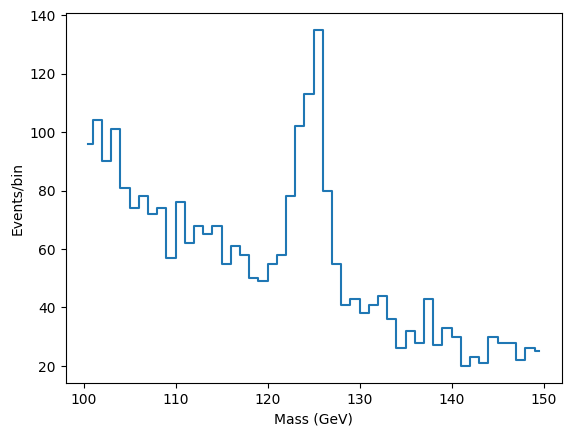

In [125]:
# Generate pseudo-data
sig=np.random.normal(m_true,sigma,int(Ns_true))

u=np.random.rand(int(Nb_true))
bkg=xmin-np.log(1-u*(1-np.exp(-lam*(xmax-xmin))))/lam

data=np.concatenate([sig,bkg])
counts,_=np.histogram(data,bins)

plt.step(centers,counts,where='mid')
plt.xlabel("Mass (GeV)")
plt.ylabel("Events/bin")
plt.show()


## Binned Poisson likelihood

In [132]:
def expected(par):
    m,kappa,Nb=par
    Ns=kappa**2*Ns_SM
    s=gauss_pdf(centers,m,sigma)
    s=s/np.sum(s)
    b=exp_pdf(centers,lam)
    b=b/np.sum(b)
    mu=Ns*s+Nb*b
    return mu


def nll(par):
    mu=expected(par)
    mu=np.clip(mu,1e-9,None)
    return np.sum(mu-counts*np.log(mu))



def nll_minuit(m,kappa,Nb):
    par = (m, kappa, Nb)     
    mu=expected(par)
    mu=np.clip(mu,1e-9,None)
    return np.sum(mu-counts*np.log(mu))


'''
x0=[124.5,0.8,2400]
res=minimize(nll,x0)
print(res)

cov = res.hess_inv

errors = np.sqrt(np.diag(cov))

print(errors)

'''

fit = Minuit(nll_minuit,
           m=125,
           kappa=1.0,
           Nb=2400)

fit.errordef = Minuit.LIKELIHOOD
fit.migrad()
fit.hesse()

cov = np.array(fit.covariance)
print(cov)

H = np.linalg.inv(cov)

print("Hessian:")
print(H)

print(fit.values)
print(fit.errors)

[[ 2.16697422e-02 -2.28104514e-04  1.37578481e-01]
 [-2.28104514e-04  1.67805600e-03 -5.09501156e-01]
 [ 1.37578481e-01 -5.09501156e-01  2.80410378e+03]]
Hessian:
[[ 4.62171850e+01  5.92061609e+00 -1.19179947e-03]
 [ 5.92061609e+00  6.31482094e+02  1.14448798e-01]
 [-1.19179947e-03  1.14448798e-01  3.77473818e-04]]
<ValueView m=124.79058030730411 kappa=1.0053256089030957 Nb=2496.7836514926125>
<ErrorView m=0.147206461133971 kappa=0.04096408178172325 Nb=52.953789108607694>


/tmp/ipykernel_2058/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


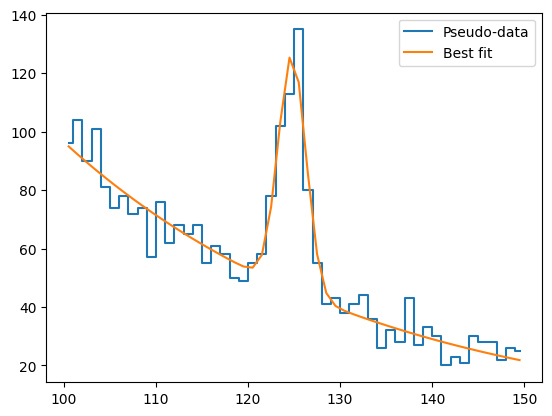

In [127]:
'''
mhat,khat,nbhat=res.x
print("Best fit mass =",mhat)
print("Best fit kappa =",khat)
print("Best fit Nb =",nbhat)

mu=expected(res.x)
'''

mhat  = fit.values["m"]
khat  = fit.values["kappa"]
nbhat = fit.values["Nb"]


plt.step(centers,counts,where='mid',label='Pseudo-data')
plt.plot(centers,mu,label='Best fit')
plt.legend()
plt.show()


## 1D Likelihood scan in mass for best values of kappa and Nb

/tmp/ipykernel_2058/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


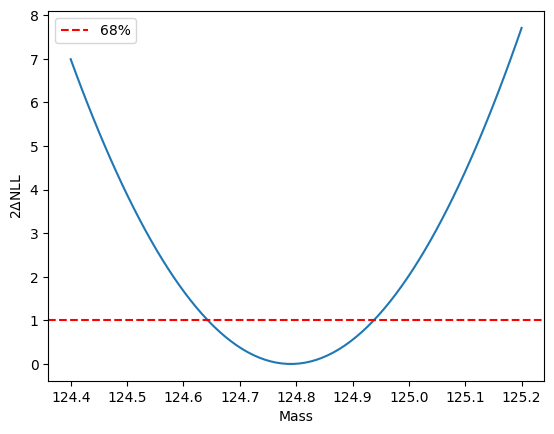

In [128]:
mscan=np.linspace(124.4,125.2,80)
vals=[]

mhat  = fit.values["m"]
khat  = fit.values["kappa"]
nbhat = fit.values["Nb"]

par = (mhat, khat, nbhat) 

for m in mscan:
    #vals.append(nll([m,khat,nbhat])-nll(res.x))
    vals.append(nll([m,khat,nbhat])-nll(par))
    #print(nll([m,khat,nbhat])-nll(res.x)) 

plt.plot(mscan,2*np.array(vals))
plt.axhline(1,color='r',ls='--',label='68%')
plt.xlabel("Mass")
plt.ylabel(r"$2\Delta$NLL")
plt.legend()
plt.show()


# Exercises

1. Double the luminosity (increase Ns_true and Nb_true).
2. Reduce the detector resolution.
3. Change kappa_true to 0.5.
4. Add a Crystal Ball signal model instead of a Gaussian.
5. Make a 2D likelihood scan in (mass, kappa).


### Do a 1D likelihood scan in kappa

/tmp/ipykernel_2058/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


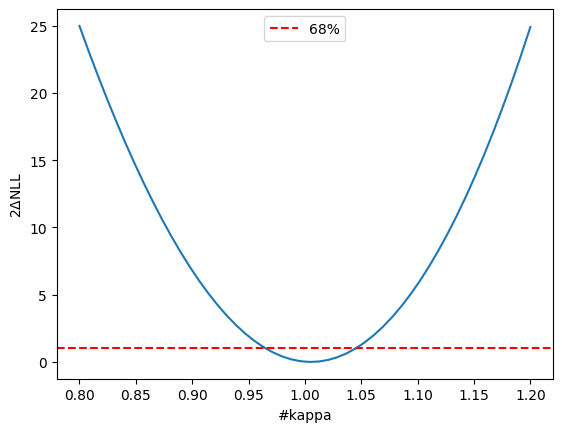

In [129]:
#kscan=np.linspace(0,2,50)
kscan=np.linspace(0.8,1.2,50)

vals=[]

mhat  = fit.values["m"]
khat  = fit.values["kappa"]
nbhat = fit.values["Nb"]

par = (mhat, khat, nbhat) 

for k in kscan:
    #vals.append(nll([mhat,k,nbhat])-nll(res.x))
    vals.append(nll([mhat,k,nbhat])-nll(par))

plt.plot(kscan,2*np.array(vals))
plt.axhline(1,color='r',ls='--',label='68%')
plt.xlabel("#kappa")
plt.ylabel(r"$2\Delta$NLL")
plt.legend()
plt.show()

### 2D likelihood scan

/tmp/ipykernel_2058/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


'\nlevels = [2.30, 5.99]\n\ncs = plt.contour(\n    K,\n    M,\n    deltaNLL,\n    levels=levels,\n    colors=["red", "white"],\n    linewidths=2\n)\n\nplt.clabel(cs, fmt={\n    2.30: "68%",\n    5.99: "95%"\n})\n\nplt.plot(\n    res.x[1],      # kappa\n    res.x[0],      # mass\n    "r*",\n    markersize=15,\n    label="Best fit"\n)\n'

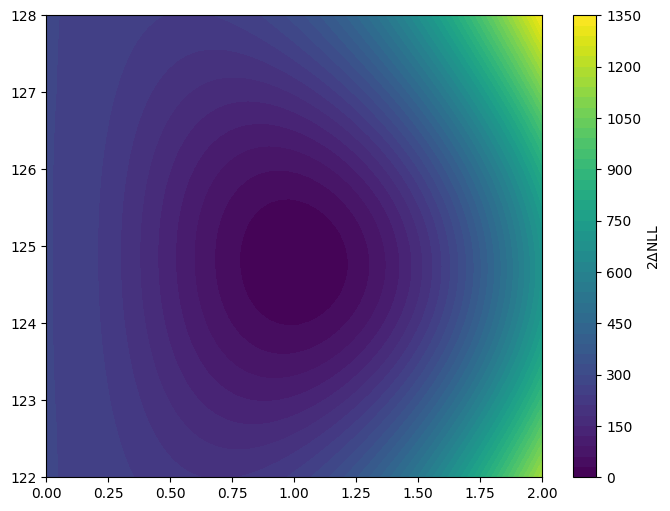

In [130]:
import numpy as np
import matplotlib.pyplot as plt

# Scan ranges
kscan = np.linspace(0, 2, 50)
mscan = np.linspace(122, 128, 80)

# Meshgrid
K, M = np.meshgrid(kscan, mscan)

# Allocate array
deltaNLL = np.zeros_like(K)

# Best-fit NLL
#nll_best = nll(res.x)

mhat  = fit.values["m"]
khat  = fit.values["kappa"]
nbhat = fit.values["Nb"]

par = (mhat, khat, nbhat) 

nll_best = nll(par)

# Fill grid
for i, m in enumerate(mscan):
    for j, k in enumerate(kscan):
        deltaNLL[i, j] = 2*(nll([m, k, nbhat]) - nll_best)

plt.figure(figsize=(8,6))

cf = plt.contourf(
    K,
    M,
    deltaNLL,
    levels=50,
    cmap="viridis"
)

plt.colorbar(cf, label=r"$2\Delta\mathrm{NLL}$")

'''
levels = [2.30, 5.99]

cs = plt.contour(
    K,
    M,
    deltaNLL,
    levels=levels,
    colors=["red", "white"],
    linewidths=2
)

plt.clabel(cs, fmt={
    2.30: "68%",
    5.99: "95%"
})

plt.plot(
    res.x[1],      # kappa
    res.x[0],      # mass
    "r*",
    markersize=15,
    label="Best fit"
)
'''

## Numerical Hessian

We compute the Hessian by finite differences around the best-fit point.

At the minimum, the Hessian of $-\ln\mathcal{L}$ approximates the inverse covariance (Fisher information):

$$
H_{ij} = \frac{\partial^2(-\ln\mathcal{L})}{\partial\theta_i\partial\theta_j}\bigg|_{\hat\theta}, \qquad \Sigma = H^{-1}
$$

In [131]:
def numerical_hessian(fun,x,h=1e-3):

    n=len(x)
    H=np.zeros((n,n))

    for i in range(n):
        for j in range(n):

            xp=x.copy()
            xm=x.copy()
            xpp=x.copy()
            xmm=x.copy()

            xp[i]+=h
            xp[j]-=h

            xm[i]-=h
            xm[j]+=h

            xpp[i]+=h
            xpp[j]+=h

            xmm[i]-=h
            xmm[j]-=h

            H[i,j]=(fun(xpp)-fun(xp)-fun(xm)+fun(xmm))/(4*h*h)

    return H

theta=res.x

H=numerical_hessian(nll,theta)

print(H)


COV = np.linalg.inv(H)
print(COV)
ERR = np.sqrt(np.abs(np.diag(COV)))

print(f"{'Parameter':<14}  {'Value':>10}  {'Uncertainty':>12}")
print('-'*40)
for name, v, e in zip(PARAM_NAMES, theta, ERR):
    print(f"{name:<14}  {v:>10.4f}  ±{e:>10.4f}")

eigvals = np.linalg.eigvalsh(H)

#print(f"\nHessian eigenvalues: {np.round(eigvals,4)}")

[[ 4.62168264e+01  5.86895567e+00 -1.18143362e-03]
 [ 5.86895567e+00  6.31478296e+02  1.14458544e-01]
 [-1.18143362e-03  1.14458544e-01  3.78349796e-04]]
[[ 2.16693252e-02 -2.26054430e-04  1.36050635e-01]
 [-2.26054430e-04  1.67781474e-03 -5.08279117e-01]
 [ 1.36050635e-01 -5.08279117e-01  2.79724645e+03]]
Parameter            Value   Uncertainty
----------------------------------------
m_H (GeV)         124.7905  ±    0.1472
κ                   1.0053  ±    0.0410
N_b              2496.7750  ±   52.8890


/tmp/ipykernel_2058/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)
